## Compare ind. networks between Dyscalculics & Controls

1. network sizes 
    - whole brain
    - NPC - L/R
    

In [1]:
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns
import os.path as op

bids_folder ='/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
#grad_folder = op.join(bids_folder, 'derivatives', 'gradients.36Pscrub3BPfilterrunFD104')
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

subList = [f'{sub:02d}' for sub in range(1, 67)]
group_assignment = pd.read_csv(op.join(bids_folder, 'group_assignment.csv')).set_index('subject')

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


250909-13:15:29,975 nipype.utils WARNING:
	 A newer version (1.10.0) of nipy/nipype is available. You are using 1.8.6
[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [2]:
from utils import get_NPC_mask

hemi = 'both'
npc_mask = get_NPC_mask(space='fsaverage5', hemi=hemi)

In [20]:
df_nets = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=range(1, 67), dtype=float)
df_nets.index.name = 'subject'
df_nets = df_nets.join(group_assignment).set_index(['group'], append=True)

only_NPC = True
for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
        if only_NPC:
            nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
            nets_fsav5[mask] = nets
            nets = nets_fsav5[npc_mask]
        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets.loc[int(sub), f'net_{int(net)}'] = count

    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')


Error processing sub-02: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-02_consensusMapping_confspec-36Pscrub3BPfilter.npy'


Normality test failed for net_6, defaulting to t-test


Text(0.5, 1.02, 'Group comparison: Network sizes \n NPC mask - True, hemi-both')

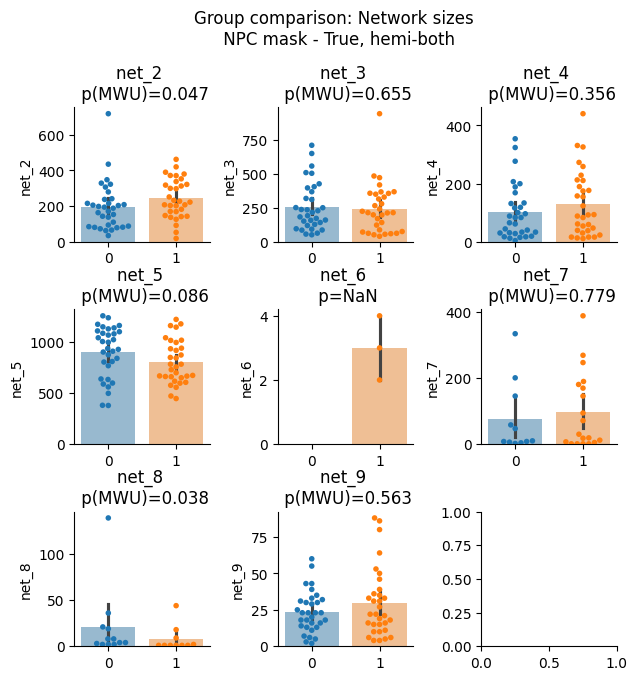

In [23]:
# between group test:
from scipy.stats import ttest_ind, mannwhitneyu, normaltest
alpha = 0.05

figure, axes = plt.subplots(3, 3, figsize=(7,7))
axs = axes.flatten()
for i, net in enumerate(df_nets.columns[:8]):
    sns.barplot(data=df_nets.reset_index(), x='group', hue='group', y=net, alpha=0.5, legend=False, ax=axs[i])
    sns.swarmplot(data=df_nets.reset_index(), x='group', hue='group', y=net, size=4, legend=False, ax=axs[i])
    
    # Convert to numeric and drop NaNs manually
    group0_data = df_nets.xs(0,0,'group')[net].dropna()
    group1_data = df_nets.xs(1,0,'group')[net].dropna()

    try:
        numeric_data = df_nets[net].dropna()
        _, pval_normal = normaltest(numeric_data)

        if pval_normal > alpha:
            stats = ttest_ind(group0_data, group1_data)
            test_type = 'T'
        else:
            stats = mannwhitneyu(group0_data, group1_data)   
            test_type = 'MWU'  
        axs[i].set(xlabel=None, title=f'{net} \n p({test_type})={stats.pvalue:.3f}')

    except:
        print(f'Normality test failed for {net}, defaulting to t-test')
        axs[i].set(xlabel=None, title=f'{net} \n p=NaN')

plt.subplots_adjust(hspace=0.5,wspace=0.5)
sns.despine()
figure.suptitle(f'Group comparison: Network sizes \n NPC mask - {only_NPC}, hemi-{hemi}', y=1.02)

In [24]:
#df_nets.columns
# remove outlier
net = 'net_2'

tmp = df_nets.drop(df_nets[net].idxmax())

# Convert to numeric and handle NaN values properly
group0_data = tmp.xs(0, level='group')[net].dropna()
group1_data = tmp.xs(1, level='group')[net].dropna()

stats = ttest_ind(group0_data, group1_data)
print(f"T-test results: statistic={stats.statistic:.3f}, p-value={stats.pvalue:.3f}")

T-test results: statistic=-2.410, p-value=0.019


In [34]:
# correlated to NPC dispersion??
#  withinNdispersion_grad-2.csv # betweenNdispersion_grad-2.csv 
npc_disp = pd.read_csv(op.join('/mnt_03/ds-dnumrisk', 'derivatives','phenotype', 'withinNdispersion-NPC_grad-2_confspec-36Pscrub3BPfilterrunFD104.csv')).set_index('subject')
df_comb = df_nets.join(npc_disp, on='subject')
#df_comb = npc_disp.join(df_nets, on='subject')


,net_2,net_3,net_4,net_5,net_6,net_7,net_8,net_9,net_-1,group,NPC_dispersion,NPC_centroid
net_2,1.000000,0.100062,0.042419,-0.674102,-0.980553,0.009515,-0.031089,0.130064,1.0,0.187186,0.413823,-0.035325
net_3,0.100062,1.000000,-0.315197,-0.577397,-0.516907,-0.217408,-0.156439,-0.033345,-1.0,-0.017629,-0.019212,-0.241841
net_4,0.042419,-0.315197,1.000000,-0.198725,0.880712,-0.145740,0.234938,-0.162884,NaN,0.130478,-0.056045,-0.094434
net_5,-0.674102,-0.577397,-0.198725,1.000000,0.594496,-0.311711,-0.396229,-0.062836,1.0,-0.219386,-0.286624,0.210961
net_6,-0.980553,-0.516907,0.880712,0.594496,1.000000,-1.000000,NaN,-0.748753,NaN,NaN,-0.202766,0.529313
net_7,0.009515,-0.217408,-0.145740,-0.311711,-1.000000,1.000000,0.839908,0.095586,NaN,0.099090,0.101208,0.030908
net_8,-0.031089,-0.156439,0.234938,-0.396229,NaN,0.839908,1.000000,-0.200381,NaN,-0.237340,-0.096201,0.143520
net_9,0.130064,-0.033345,-0.162884,-0.062836,-0.748753,0.095586,-0.200381,1.000000,1.0,0.151690,0.410341,-0.347455
net_-1,1.000000,-1.000000,NaN,1.000000,NaN,NaN,NaN,1.000000,1.0,1.000000,1.000000,-1.000000
group,0.187186,-0.017629,0.130478,-0.219386,NaN,0.099090,-0.237340,0.151690,1.0,1.000000,0.322676,-0.206402


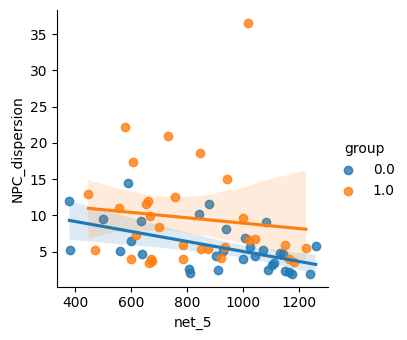

In [36]:
n_net = 'net_5'
sns.lmplot(data= df_comb, x=n_net, y='NPC_dispersion', hue='group', aspect=1, height=3.5)
df_comb.corr()

In [32]:
df_comb.sort_values('net_2', ascending=False)

,,net_2,net_3,net_4,net_5,net_6,net_7,net_8,net_9,net_-1,group,NPC_dispersion,NPC_centroid
subject,group,,,,,,,,,,,,
10,0,717.0,251.0,134.0,381.0,NaN,4.0,NaN,23.0,NaN,0.0,5.209099,2.317501
33,1,462.0,213.0,175.0,447.0,NaN,180.0,NaN,33.0,NaN,1.0,12.918440,1.467134
53,0,435.0,648.0,5.0,379.0,NaN,NaN,NaN,43.0,NaN,0.0,11.948481,-0.992880
38,1,420.0,350.0,60.0,674.0,NaN,NaN,NaN,6.0,NaN,1.0,3.640270,0.051837
45,1,390.0,225.0,40.0,730.0,NaN,94.0,NaN,31.0,NaN,1.0,20.902368,0.967081
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,0,64.0,97.0,29.0,1239.0,NaN,58.0,NaN,23.0,NaN,0.0,1.891885,2.003238
25,1,54.0,939.0,39.0,472.0,NaN,NaN,NaN,6.0,NaN,1.0,5.258440,0.323504
66,0,36.0,129.0,NaN,1175.0,NaN,145.0,2.0,23.0,NaN,0.0,1.942982,0.517751


## OLD

In [ ]:
nets_all = []
df_nets = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=range(1, 67))
subs = []
for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
        nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
        nets_fsav5[mask] = nets
        nets_all.append(nets_fsav5)

        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets.loc[int(sub), f'net_{net}'] = count

        subs.append(int(sub))
    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')

df_nets = pd.DataFrame(nets_all, index=subs)
df_nets.index.name = 'subject'
df_nets = df_nets.join(group_assignment).set_index(['group'], append=True)

In [ ]:
# copy files that did not fo through in first network fitting round 
miss_sub_list = [5, 6, 41, 45, 47, 53, 59, 62]
source_net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full')
target_net_folder = net_folder

import shutil 
import os
import glob 
for sub in miss_sub_list:
    old_file_pattern = op.join(source_net_folder, f"sub-{sub:02d}*_consensusMapping*.npy")
    old_file = glob.glob(old_file_pattern)[0]
    #old_file = op.join(source_net_folder, f'sub-{sub:02d}_consensusMapping_threshs-0.03-0.04-0.05-0.1-0.2-0.4_confspec-36Pscrub3BPfilter.npy')
    new_file = op.join(target_net_folder, f'sub-{sub:02d}_consensusMapping_confspec-36Pscrub3BPfilter.npy')
    if not os.path.exists(new_file):
        shutil.copy(old_file, new_file)
        print(f'Copied {old_file} to {new_file}')
